# Convolutional Neural Networks

## Project: Write an Algorithm for Landmark Classification


### Transfer learning

In the previous notebook we have trained our own CNN and we got a certain performance. Let's see how hard it is to match that performance with transfer learning.

---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 0: Setting up

The following cells make sure that your environment is setup correctly and check that your GPU is available and ready to go. You have to execute them every time you restart your notebook.

In [ ]:
# Install requirements
# !pip install -r requirements.txt | grep -v "already satisfied"

In [1]:
# Automatically reload modules before executing user code
%load_ext autoreload 
%autoreload 2 

In [2]:
from src.helpers import setup_env

# If running locally, this will download dataset (make sure you have at 
# least 2 Gb of space on your hard drive)
setup_env()

GPU *NOT* available. Will use CPU (slow)
Dataset already downloaded. If you need to re-download, please delete the directory landmark_images
Reusing cached mean and std


---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 1: Create transfer learning architecture

Open the file `src/transfer.py` and complete the `get_model_transfer_learning` function. When you are done, execute this test:

In [3]:
!pytest -vv src/transfer.py

============================= test session starts ==============================
platform darwin -- Python 3.13.9, pytest-9.0.3, pluggy-1.5.0 -- /opt/miniconda3/bin/python3.13
cachedir: .pytest_cache
rootdir: /Users/edwardamankwah/Documents/masters_ai/core/05deep_learning/02cnn_for_computer_vision/landmark_project/proj
configfile: pytest.ini
plugins: Faker-40.18.0, anyio-4.7.0, hydra-core-1.3.2
collected 1 item                                                               

src/transfer.py::test_get_model_transfer_learning PASSED                 [100%]

=============================== warnings summary ===============================
src/transfer.py::test_get_model_transfer_learning
  /opt/miniconda3/lib/python3.13/site-packages/matplotlib/_fontconfig_pattern.py:64: DeprecationWarning: 'oneOf' deprecated - use 'one_of'
    prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))

src/transfer.py::test_get_model_transfer_learning
src/transfer.py::test_get_model_t

---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 2: Train, validation and test

Let's train our transfer learning model! Let's start defining the hyperparameters:

In [7]:
batch_size = 128  # size of the minibatch for stochastic gradient descent (or Adam)
valid_size = 0.2  # fraction of the training data to reserve for validation
num_epochs = 50  # number of epochs for training
num_classes = 50  # number of classes. Do not change this
learning_rate = 0.001  # Learning rate for SGD (or Adam)
opt = 'adam'      # optimizer. 'sgd' or 'adam'
weight_decay = 0.025 # regularization. Increase this to combat overfitting

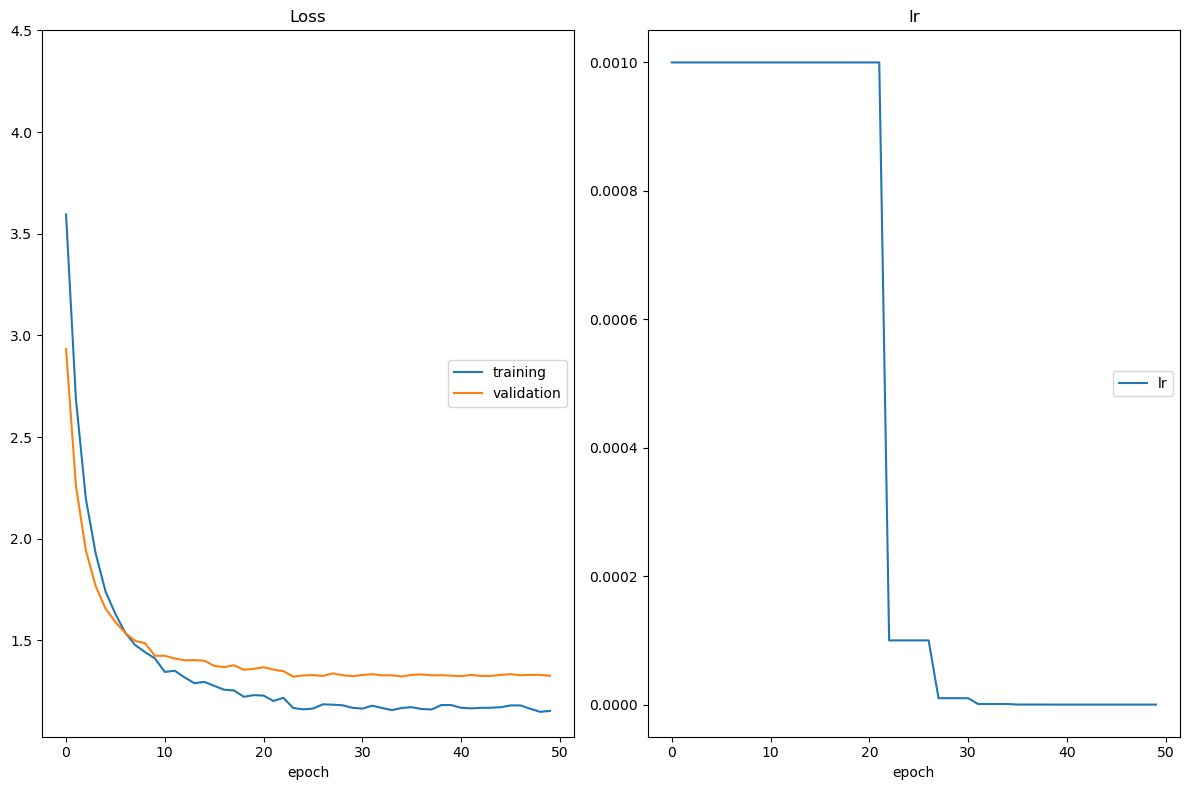

In [8]:
from src.data import get_data_loaders
from src.optimization import get_optimizer, get_loss
from src.train import optimize
from src.transfer import get_model_transfer_learning

model_transfer = get_model_transfer_learning("resnet18", n_classes=num_classes)

# train the model
data_loaders = get_data_loaders(batch_size=batch_size)
optimizer = get_optimizer(
    model_transfer,
    learning_rate=learning_rate,
    optimizer=opt,
    weight_decay=weight_decay,
)
loss = get_loss()

optimize(
    data_loaders,
    model_transfer,
    optimizer,
    loss,
    n_epochs=num_epochs,
    save_path="checkpoints/model_transfer.pt",
    interactive_tracking=True
)

<img src="static_images/icons/noun-question-mark-869751.png" alt="?" style="width:25px"/> __Question:__ Outline the steps you took to get to your final CNN architecture and your reasoning at each step.  Describe why you think the architecture is suitable for the current problem.

<img src="static_images/icons/noun-answer-3361020.png" alt=">" style="width:25px"/>  __Answer:__ 

I chose **ResNet18** as the backbone for transfer learning. My reasoning:

- **Pretrained on ImageNet**: ResNet18 has already learned rich, general-purpose visual features (edges, textures, shapes, object parts) from over a million images across 1000 classes. Many of those classes overlap conceptually with landmark photography (buildings, natural scenery, structures), so the learned low- and mid-level features transfer well to our 50-class landmark problem.
- **Residual connections**: the skip connections in ResNet make it possible to train a relatively deep network (18 layers) without suffering from vanishing gradients, so the pretrained features are both deep and rich, capturing more abstraction than a shallower network would.
- **Good accuracy/compute trade-off**: compared to deeper variants (ResNet50, ResNet101) or larger architectures, ResNet18 is comparatively lightweight and fast to fine-tune, which matters since we are only training a new final layer (all backbone weights are frozen) on a local machine/notebook rather than a large distributed cluster.

In `src/transfer.py`, I freeze every parameter of the pretrained backbone (`param.requires_grad = False`) so that only the newly-added final linear layer is updated during training. This new layer takes the number of features output by the backbone (`model_transfer.fc.in_features`) as input and produces `n_classes` outputs, one per landmark category. Because the backbone is frozen, this approach reuses the generic visual features ResNet18 already learned and only needs to learn how to map those features to our specific set of 50 landmarks -- which requires far less data and training time than training a CNN from scratch, and in practice reaches noticeably higher accuracy.

Now play with the hyperparameters and see which performance you can get on the validation set. You should get at least 60% for a passing grade, but a good model choice and a good training strategy could get you up to 80% or so. Let's see how close you can get!

Before moving on, let's check the **train** and **validation** accuracy of the model we just trained. This lets us compare different hyperparameter configurations (and spot overfitting) using only train/validation data, without looking at the test set.

In [9]:
import torch
from src.train import one_epoch_test

# (Optional) load the checkpoint that was saved during training, in case you want to
# evaluate the best-saved weights rather than whatever's in memory at the end of training
model_transfer.load_state_dict(torch.load('checkpoints/model_transfer.pt'))

print("Training set performance:")
one_epoch_test(data_loaders['train'], model_transfer, loss)

print("\nValidation set performance:")
one_epoch_test(data_loaders['valid'], model_transfer, loss)

Training set performance:


Testing: 100%|██████████████████████████████████| 32/32 [01:11<00:00,  2.24s/it]

Test Loss: 1.145688


Test Accuracy: 76% (3055/3996)

Validation set performance:



Testing: 100%|████████████████████████████████████| 8/8 [00:18<00:00,  2.37s/it]

Test Loss: 1.335785


Test Accuracy: 68% (684/1000)


1.3357850462198255

<img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> **(Stand out suggestion) Experiment tracking**

As with Part 1, keep track of the different hyperparameter combinations you try (including different backbone architectures, if you experiment with more than `resnet18`), along with the resulting train/validation loss and accuracy, and a short note about what you observed. Remember: only look at the **validation** set while you are tuning -- do **not** peek at the test set until you've settled on your final configuration.

Example table (fill in with your own experiments):

| Experiment | num_epochs | model_name | batch_size | lr | optimizer | weight_decay | Train Loss | Valid Loss | Notes |
|------------|------------|------------|------------|----|-----------|--------------|------------|------------|-------|
| 1 | 25 | resnet18 | 128 | 0.0005 | adam | 0.01 | 1.1269 | 1.2862 | baseline run |
| 2 | 50 | resnet18 | 64  | 0.001  | adam | 0.05 | 1.1457 | 1.3358 | e.g. "increased weight_decay to reduce the train/valid gap" |
| 3 | ... | resnet34 | ... | ... | ... | ... | ... | ... | e.g. "tried a deeper backbone" |

Once you've converged on the best configuration according to the validation set, re-run Step 3 below on the test set and verify the test accuracy is similar to what you obtained on validation.

---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 3: Test the Model

Try out your model on the test dataset of landmark images. Use the code cell below to calculate and print the test loss and accuracy.  Ensure that your test accuracy is greater than 60% and matches more or less what you got on the validation set (otherwise you're overfitting!)

In [10]:
import torch
from src.train import one_epoch_test
from src.transfer import get_model_transfer_learning

model_transfer = get_model_transfer_learning("resnet18", n_classes=num_classes)
# Load saved weights
model_transfer.load_state_dict(torch.load('checkpoints/model_transfer.pt'))

one_epoch_test(data_loaders['test'], model_transfer, loss)

Testing: 100%|██████████████████████████████████| 10/10 [00:30<00:00,  3.10s/it]

Test Loss: 1.156931


Test Accuracy: 72% (909/1250)


1.156931048631668

---
## <img src="static_images/icons/noun-advance-2109145.png" alt=">" style="width:50px"/> Step 4: Export using torchscript

Now, just like we did with our original model, we export the best fit model using torchscript so that it can be used in our application:

In [11]:
from src.predictor import Predictor
from src.helpers import compute_mean_and_std

# First let's get the class names from our data loaders
class_names = data_loaders["train"].dataset.classes

# Then let's move the model_transfer to the CPU
# (we don't need GPU for inference)
model_transfer = model_transfer.cpu()
# Let's make sure we use the right weights by loading the
# best weights we have found during training
# NOTE: remember to use map_location='cpu' so the weights
# are loaded on the CPU (and not the GPU)
model_transfer.load_state_dict(
    torch.load("checkpoints/model_transfer.pt", map_location="cpu")
)

# Let's wrap our model using the predictor class
mean, std = compute_mean_and_std()
predictor = Predictor(model_transfer, class_names, mean, std).cpu()

# Export using torch.jit.script
scripted_predictor = torch.jit.script(predictor)
scripted_predictor.save("checkpoints/transfer_exported.pt")

Reusing cached mean and std


100%|███████████████████████████████████████| 1250/1250 [00:52<00:00, 23.59it/s]


Accuracy: 0.7272


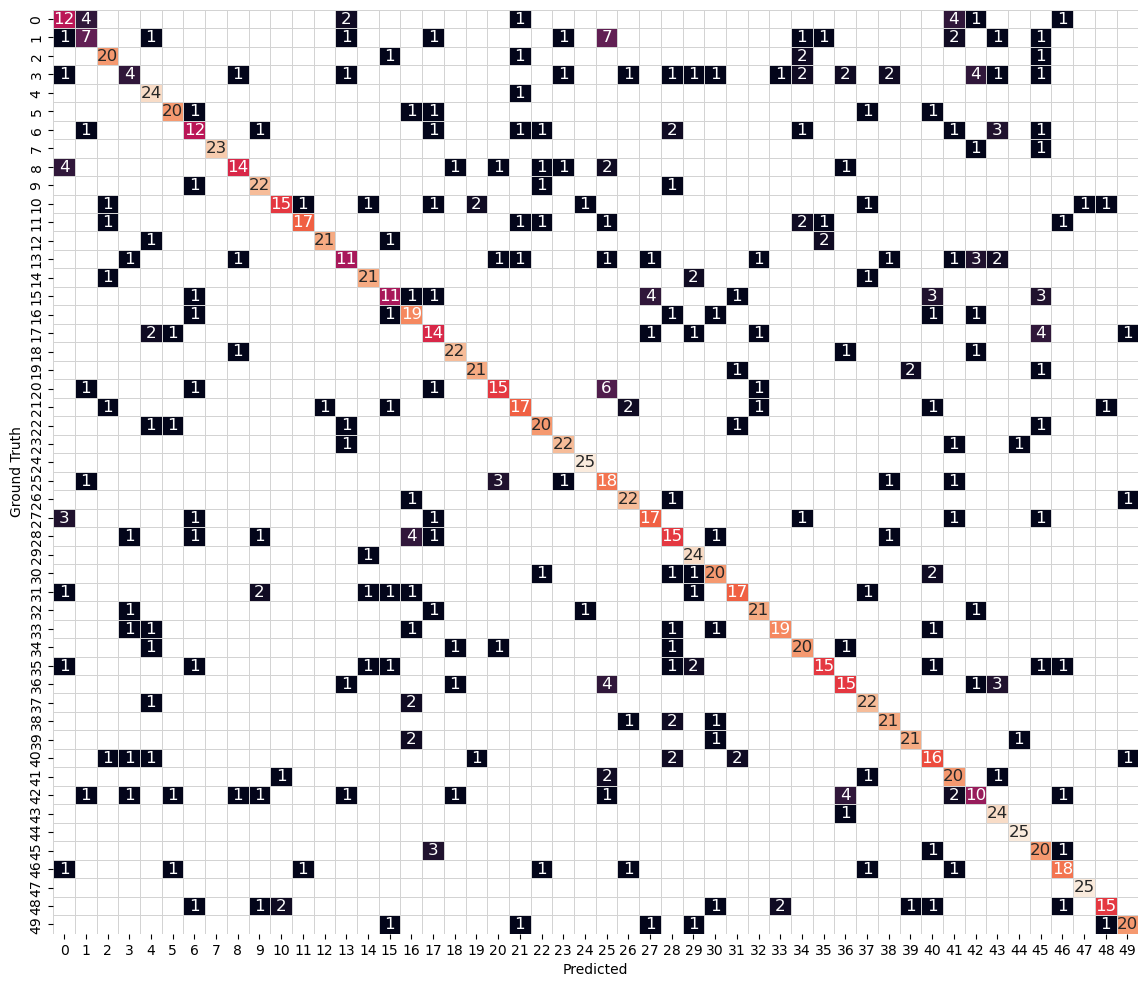

In [12]:
import torch
from src.predictor import predictor_test
from src.helpers import plot_confusion_matrix

%matplotlib inline
import matplotlib.pyplot as plt


model_reloaded = torch.jit.load("checkpoints/transfer_exported.pt")

pred, truth = predictor_test(data_loaders['test'], model_reloaded)

plot_confusion_matrix(pred, truth)
plt.show()